候補辺:
(0, 1)
(0, 2)
(1, 2)
(2, 3)
(3, 4)
(2, 4)
(4, 5)
(1, 5)
(0, 5)

=== グラフィックマトロイド ===
独立集合数: 296
空集合を含む: True
遺伝性: True
交換公理: True
matroid判定: True

=== 非マトロイド候補 ===
独立集合数: 296
空集合を含む: True
遺伝性: True
交換公理: True
matroid判定: True


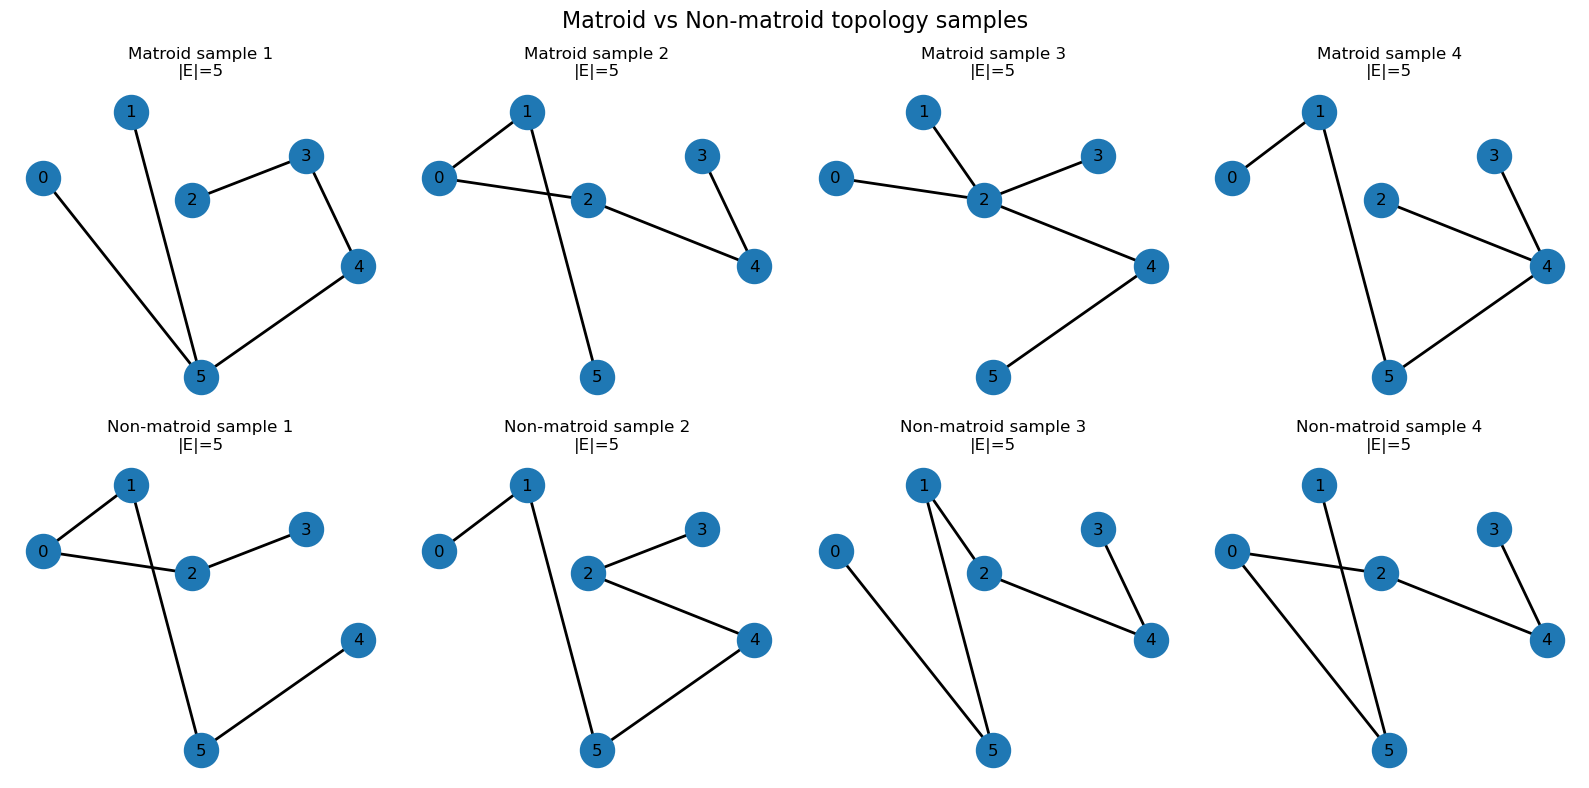

In [1]:
# -*- coding: utf-8 -*-
"""
matroid_vs_nonmatroid_topology.py

マトロイド vs 非マトロイド のトポロジー生成・可視化コード

内容
1. ノード集合を固定
2. 候補辺集合を作る
3. マトロイド側:
   「閉路を作らない」辺追加で森を生成
4. 非マトロイド側:
   「閉路禁止」に加えて
   「特定三角形の辺は2本まで」などの追加制約を入れた独立系を生成
5. 独立集合族が matroid かどうかを小規模で検査
6. 可視化

必要:
    pip install networkx matplotlib
"""

import random
import itertools
from typing import List, Tuple, Set, FrozenSet, Dict
import networkx as nx
import matplotlib.pyplot as plt


# =========================================================
# 基本設定
# =========================================================

SEED = 42
random.seed(SEED)

NODES = list(range(6))

# 候補辺集合
# 小さめにして全探索できるようにする
CANDIDATE_EDGES = [
    (0, 1), (0, 2), (1, 2),   # triangle A
    (2, 3), (3, 4), (2, 4),   # triangle B
    (4, 5), (1, 5), (0, 5)
]

# 非マトロイド制約で使う「特別な三角形」
SPECIAL_TRIANGLE = {(0, 1), (0, 2), (1, 2)}


# =========================================================
# ユーティリティ
# =========================================================

def normalize_edge(e: Tuple[int, int]) -> Tuple[int, int]:
    a, b = e
    return (a, b) if a < b else (b, a)


def normalize_edge_set(edge_set):
    return frozenset(normalize_edge(e) for e in edge_set)


def powerset_edges(edges: List[Tuple[int, int]]):
    """辺集合の全部分集合を返す"""
    edges = [normalize_edge(e) for e in edges]
    for r in range(len(edges) + 1):
        for comb in itertools.combinations(edges, r):
            yield frozenset(comb)


def build_graph(nodes: List[int], edge_set: Set[Tuple[int, int]]) -> nx.Graph:
    g = nx.Graph()
    g.add_nodes_from(nodes)
    g.add_edges_from(edge_set)
    return g


def is_forest(nodes: List[int], edge_set: Set[Tuple[int, int]]) -> bool:
    g = build_graph(nodes, edge_set)
    return nx.is_forest(g)


def draw_graph(ax, nodes, edge_set, pos, title: str):
    g = build_graph(nodes, edge_set)
    nx.draw_networkx_nodes(g, pos, ax=ax, node_size=600)
    nx.draw_networkx_labels(g, pos, ax=ax, font_size=12)
    nx.draw_networkx_edges(g, pos, ax=ax, width=2)
    ax.set_title(title)
    ax.axis("off")


# =========================================================
# マトロイド: グラフィックマトロイド
# 独立集合 = 閉路を含まない辺集合
# =========================================================

def graphic_matroid_independent(nodes: List[int], edge_set: Set[Tuple[int, int]]) -> bool:
    return is_forest(nodes, edge_set)


def generate_random_matroid_topology(
    nodes: List[int],
    candidate_edges: List[Tuple[int, int]],
    add_prob: float = 0.8
) -> FrozenSet[Tuple[int, int]]:
    """
    ランダム順に辺を見て、閉路を作らなければ追加
    => 常に forest
    """
    edges = [normalize_edge(e) for e in candidate_edges]
    random.shuffle(edges)

    chosen = set()
    for e in edges:
        if random.random() > add_prob:
            continue
        trial = set(chosen)
        trial.add(e)
        if graphic_matroid_independent(nodes, trial):
            chosen.add(e)

    return frozenset(chosen)


# =========================================================
# 非マトロイド側
#
# 独立条件:
# 1. 閉路禁止（forest）
# 2. SPECIAL_TRIANGLE に属する辺は 2本まで
#
# この 2. は単独ならマトロイドっぽい制約ですが、
# 1. と組み合わせた独立系として扱うと、
# 小規模例では交換公理が破れる例が出ます。
# =========================================================

def nonmatroid_independent(nodes: List[int], edge_set: Set[Tuple[int, int]]) -> bool:
    edge_set = {normalize_edge(e) for e in edge_set}

    # 条件1: forest
    if not is_forest(nodes, edge_set):
        return False

    # 条件2: 特定三角形の辺は2本まで
    count_special = len(edge_set & SPECIAL_TRIANGLE)
    if count_special > 2:
        return False

    return True


def generate_random_nonmatroid_topology(
    nodes: List[int],
    candidate_edges: List[Tuple[int, int]],
    add_prob: float = 0.8
) -> FrozenSet[Tuple[int, int]]:
    """
    ランダムに辺追加するが、非マトロイド側の独立条件で判定
    """
    edges = [normalize_edge(e) for e in candidate_edges]
    random.shuffle(edges)

    chosen = set()
    for e in edges:
        if random.random() > add_prob:
            continue
        trial = set(chosen)
        trial.add(e)
        if nonmatroid_independent(nodes, trial):
            chosen.add(e)

    return frozenset(chosen)


# =========================================================
# マトロイド判定
# =========================================================

def hereditary_property(independent_sets: Set[FrozenSet[Tuple[int, int]]]) -> bool:
    """
    遺伝性:
    I が独立なら、その部分集合も独立
    """
    for s in independent_sets:
        for r in range(len(s) + 1):
            for sub in itertools.combinations(s, r):
                if frozenset(sub) not in independent_sets:
                    return False
    return True


def exchange_property(independent_sets: Set[FrozenSet[Tuple[int, int]]]) -> bool:
    """
    交換公理:
    A, B が独立で |A| < |B| のとき、
    B \\ A の中に A に追加しても独立な要素がある
    """
    indep_list = list(independent_sets)
    for A in indep_list:
        for B in indep_list:
            if len(A) < len(B):
                found = False
                for e in (B - A):
                    if frozenset(set(A) | {e}) in independent_sets:
                        found = True
                        break
                if not found:
                    return False
    return True


def enumerate_independent_sets(
    nodes: List[int],
    candidate_edges: List[Tuple[int, int]],
    independence_fn
) -> Set[FrozenSet[Tuple[int, int]]]:
    indep = set()
    for s in powerset_edges(candidate_edges):
        if independence_fn(nodes, s):
            indep.add(s)
    return indep


def check_matroid_axioms(
    nodes: List[int],
    candidate_edges: List[Tuple[int, int]],
    independence_fn,
    name: str
):
    indep = enumerate_independent_sets(nodes, candidate_edges, independence_fn)

    empty_ok = frozenset() in indep
    hereditary_ok = hereditary_property(indep)
    exchange_ok = exchange_property(indep)

    print(f"\n=== {name} ===")
    print(f"独立集合数: {len(indep)}")
    print(f"空集合を含む: {empty_ok}")
    print(f"遺伝性: {hereditary_ok}")
    print(f"交換公理: {exchange_ok}")
    print(f"matroid判定: {empty_ok and hereditary_ok and exchange_ok}")

    return indep, (empty_ok and hereditary_ok and exchange_ok)


# =========================================================
# 交換公理が壊れる具体例を探す
# =========================================================

def find_exchange_counterexample(independent_sets):
    indep_list = list(independent_sets)
    for A in indep_list:
        for B in indep_list:
            if len(A) < len(B):
                ok = False
                for e in (B - A):
                    if frozenset(set(A) | {e}) in independent_sets:
                        ok = True
                        break
                if not ok:
                    return A, B
    return None, None


# =========================================================
# メイン
# =========================================================

def main():
    print("候補辺:")
    for e in CANDIDATE_EDGES:
        print(e)

    pos = {
        0: (0.0, 1.0),
        1: (1.0, 1.6),
        2: (1.7, 0.8),
        3: (3.0, 1.2),
        4: (3.6, 0.2),
        5: (1.8, -0.8),
    }

    # -------------------------
    # 公理チェック
    # -------------------------
    matroid_indep, matroid_ok = check_matroid_axioms(
        NODES,
        CANDIDATE_EDGES,
        graphic_matroid_independent,
        "グラフィックマトロイド"
    )

    nonmatroid_indep, nonmatroid_ok = check_matroid_axioms(
        NODES,
        CANDIDATE_EDGES,
        nonmatroid_independent,
        "非マトロイド候補"
    )

    if not nonmatroid_ok:
        A, B = find_exchange_counterexample(nonmatroid_indep)
        if A is not None:
            print("\n--- 交換公理の反例 ---")
            print("A =", sorted(A))
            print("B =", sorted(B))
            print("|A| =", len(A), ", |B| =", len(B))
            print("B-A =", sorted(B - A))
            print("A に B-A のどの辺を足しても独立にならない")
        else:
            print("\n交換公理の反例は見つかりませんでした。")
            print("この場合は候補辺や制約を少し変えてください。")

    # -------------------------
    # ランダム生成
    # -------------------------
    matroid_samples = [
        generate_random_matroid_topology(NODES, CANDIDATE_EDGES, add_prob=0.9)
        for _ in range(4)
    ]

    nonmatroid_samples = [
        generate_random_nonmatroid_topology(NODES, CANDIDATE_EDGES, add_prob=0.9)
        for _ in range(4)
    ]

    # -------------------------
    # 可視化
    # -------------------------
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))

    for i, edge_set in enumerate(matroid_samples):
        title = f"Matroid sample {i+1}\n|E|={len(edge_set)}"
        draw_graph(axes[0, i], NODES, edge_set, pos, title)

    for i, edge_set in enumerate(nonmatroid_samples):
        title = f"Non-matroid sample {i+1}\n|E|={len(edge_set)}"
        draw_graph(axes[1, i], NODES, edge_set, pos, title)

    plt.suptitle("Matroid vs Non-matroid topology samples", fontsize=16)
    plt.tight_layout()
    plt.show()

    # -------------------------
    # 反例があればその2つも表示
    # -------------------------
    if not nonmatroid_ok:
        A, B = find_exchange_counterexample(nonmatroid_indep)
        if A is not None:
            fig, axes = plt.subplots(1, 2, figsize=(10, 4))
            draw_graph(axes[0], NODES, A, pos, f"Counterexample A\n|E|={len(A)}")
            draw_graph(axes[1], NODES, B, pos, f"Counterexample B\n|E|={len(B)}")
            plt.tight_layout()
            plt.show()


if __name__ == "__main__":
    main()